# Time-Series Classification

The objective of this notebook is to define and solve a binary time-series classification task using the preprocessed multivariate time-series windows.

The target variable is the binary label `sii_binary`, denoted here as `target`. Each observation is a multivariate time-series window. Since multiple windows may belong to the same subject, all train/test splits are performed at subject level to avoid data leakage.

The classification task is solved using:
1. KNN with Euclidean distance;
2. KNN with DTW distance;
3. Shapelet-based classification;
4. ROCKET as an additional time-series classification method.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeClassifierCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import pairwise_distances

random_state = 42

In [2]:
# Load preprocessed and approximation outputs

import pickle
import pandas as pd
import numpy as np
import os

preprocessed_path = "../dataset/CMI_timeseries_preprocessed_outputs.pkl"
approximation_path = "../dataset/CMI_timeseries_approximation_outputs.pkl"
metadata_path = "../dataset/CMI_timeseries_metadata_filtered.pkl"

for path in [preprocessed_path, approximation_path, metadata_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")

with open(preprocessed_path, "rb") as f:
    preprocessed_outputs = pickle.load(f)

with open(approximation_path, "rb") as f:
    approximation_outputs = pickle.load(f)

metadata_df = pd.read_pickle(metadata_path)

print("Preprocessed outputs keys:")
print(preprocessed_outputs.keys())

print("\nApproximation outputs keys:")
print(approximation_outputs.keys())

print("\nMetadata shape:", metadata_df.shape)
display(metadata_df.head())

Preprocessed outputs keys:
dict_keys(['CMI_timeseries_preprocessed', 'CMI_timeseries_global_scaled', 'CMI_timeseries_subject_scaled', 'signal_cols', 'id_col', 'target_col', 'target_df', 'filtered_target_df', 'non_wear_df', 'hampel_summary_df'])

Approximation outputs keys:
dict_keys(['X_paa_global', 'X_paa_subject', 'sax_df', 'signal_cols', 'id_col', 'target_col', 'n_segments', 'alphabet_size', 'signal_to_sax'])

Metadata shape: (4310, 3)


,window_pos,subject_id,target
0,0,2265,0
1,1,3042,1
2,2,1647,1
3,3,736,0
4,4,1044,0


In [3]:
# Extract arrays/lists from loaded dictionaries

CMI_timeseries_global_scaled = preprocessed_outputs["CMI_timeseries_global_scaled"]
CMI_timeseries_subject_scaled = preprocessed_outputs["CMI_timeseries_subject_scaled"]

X_paa_global = approximation_outputs["X_paa_global"]
X_paa_subject = approximation_outputs["X_paa_subject"]

print("Global-scaled time series:", len(CMI_timeseries_global_scaled))
print("Subject-wise-scaled time series:", len(CMI_timeseries_subject_scaled))
print("X_paa_global shape:", X_paa_global.shape)
print("X_paa_subject shape:", X_paa_subject.shape)

display(metadata_df["target"].value_counts().sort_index())

Global-scaled time series: 4310
Subject-wise-scaled time series: 4310
X_paa_global shape: (4310, 50, 6)
X_paa_subject shape: (4310, 50, 6)


target
0    2888
1    1422
Name: count, dtype: int64

In [4]:
# Extract preprocessed and approximation objects

print("Preprocessed keys:")
print(preprocessed_outputs.keys())

print("\nApproximation keys:")
print(approximation_outputs.keys())

Preprocessed keys:
dict_keys(['CMI_timeseries_preprocessed', 'CMI_timeseries_global_scaled', 'CMI_timeseries_subject_scaled', 'signal_cols', 'id_col', 'target_col', 'target_df', 'filtered_target_df', 'non_wear_df', 'hampel_summary_df'])

Approximation keys:
dict_keys(['X_paa_global', 'X_paa_subject', 'sax_df', 'signal_cols', 'id_col', 'target_col', 'n_segments', 'alphabet_size', 'signal_to_sax'])


In [5]:
# Extract time-series datasets

CMI_timeseries_global_scaled = preprocessed_outputs["CMI_timeseries_global_scaled"]
CMI_timeseries_subject_scaled = preprocessed_outputs["CMI_timeseries_subject_scaled"]

X_paa_global = approximation_outputs["X_paa_global"]
X_paa_subject = approximation_outputs["X_paa_subject"]

print("Global-scaled time series:", len(CMI_timeseries_global_scaled))
print("Subject-wise-scaled time series:", len(CMI_timeseries_subject_scaled))
print("X_paa_global shape:", X_paa_global.shape)
print("X_paa_subject shape:", X_paa_subject.shape)

print("\nMetadata shape:", metadata_df.shape)
display(metadata_df.head())

print("\nTarget distribution:")
display(metadata_df["target"].value_counts().sort_index())

Global-scaled time series: 4310
Subject-wise-scaled time series: 4310
X_paa_global shape: (4310, 50, 6)
X_paa_subject shape: (4310, 50, 6)

Metadata shape: (4310, 3)


,window_pos,subject_id,target
0,0,2265,0
1,1,3042,1
2,2,1647,1
3,3,736,0
4,4,1044,0



Target distribution:


target
0    2888
1    1422
Name: count, dtype: int64

## Classification task

The classification task is defined as a binary time-series classification problem. Each observation is a multivariate temporal window described by the six selected signals: `X`, `Y`, `Z`, `enmo`, `anglez`, and `light`. The target variable is the binary label `sii_binary`, stored as `target`.

The goal is therefore to learn a function mapping each multivariate time-series window to its binary class label. Since multiple windows may belong to the same subject, the train/test split is performed at subject level using `subject_id` as grouping variable. This prevents data leakage caused by windows from the same subject appearing in both training and test sets.

Although the prediction unit is the time-series window, the validation protocol is subject-independent: all windows from a given subject are assigned either to the training set or to the test set, never to both.

In [6]:
# Prepare classification arrays

X_ts = X_paa_global.copy()
X_ts_subject = X_paa_subject.copy()

y = metadata_df["target"].to_numpy()
groups = metadata_df["subject_id"].to_numpy()

print("X_ts shape:", X_ts.shape)
print("X_ts_subject shape:", X_ts_subject.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)

assert X_ts.shape[0] == len(y) == len(groups), "Mismatch between X, y and groups."

X_ts shape: (4310, 50, 6)
X_ts_subject shape: (4310, 50, 6)
y shape: (4310,)
groups shape: (4310,)


In [9]:
# Subject-level train/test split

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=random_state
)

train_idx, test_idx = next(gss.split(X_ts, y, groups=groups))

X_train_ts = X_ts[train_idx]
X_test_ts = X_ts[test_idx]

X_train_subject_ts = X_ts_subject[train_idx]
X_test_subject_ts = X_ts_subject[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

groups_train = groups[train_idx]
groups_test = groups[test_idx]

print("Train time-series shape:", X_train_ts.shape)
print("Test time-series shape:", X_test_ts.shape)

print("\nTrain target distribution:")
display(pd.Series(y_train).value_counts().sort_index())

print("\nTest target distribution:")
display(pd.Series(y_test).value_counts().sort_index())

print("\nNumber of train subjects:", len(np.unique(groups_train)))
print("Number of test subjects:", len(np.unique(groups_test)))
print("Subject overlap:", len(set(groups_train).intersection(set(groups_test))))

Train time-series shape: (3124, 50, 6)
Test time-series shape: (1186, 50, 6)

Train target distribution:


0    2078
1    1046
Name: count, dtype: int64


Test target distribution:


0    810
1    376
Name: count, dtype: int64


Number of train subjects: 281
Number of test subjects: 94
Subject overlap: 0


In [10]:
# Flatten PAA representation for sklearn classifiers

X_train_flat = X_train_ts.reshape(X_train_ts.shape[0], -1)
X_test_flat = X_test_ts.reshape(X_test_ts.shape[0], -1)

print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)

X_train_flat shape: (3124, 300)
X_test_flat shape: (1186, 300)


In [11]:
# Evaluation function for classification models

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

def evaluate_classifier(model_name, y_true, y_pred, y_score=None):
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

    if y_score is not None:
        try:
            results["roc_auc"] = roc_auc_score(y_true, y_score)
        except Exception:
            results["roc_auc"] = np.nan

    print(f"\n{model_name}")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(model_name)
    plt.show()

    return results

Fitting KNN Euclidean with k=1

KNN Euclidean k=1
              precision    recall  f1-score   support

           0       0.68      0.70      0.69       810
           1       0.30      0.27      0.28       376

    accuracy                           0.57      1186
   macro avg       0.49      0.49      0.49      1186
weighted avg       0.56      0.57      0.56      1186



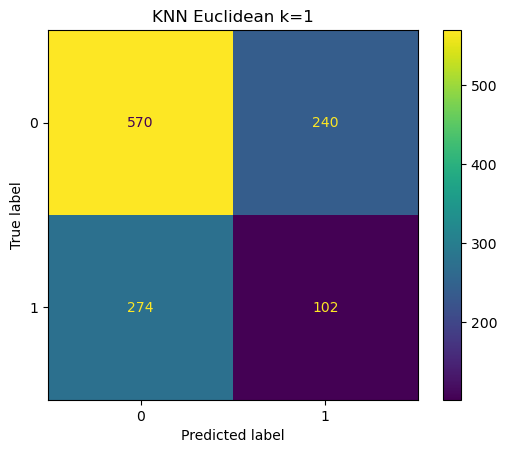

Fitting KNN Euclidean with k=3

KNN Euclidean k=3
              precision    recall  f1-score   support

           0       0.69      0.79      0.73       810
           1       0.33      0.22      0.27       376

    accuracy                           0.61      1186
   macro avg       0.51      0.51      0.50      1186
weighted avg       0.57      0.61      0.59      1186



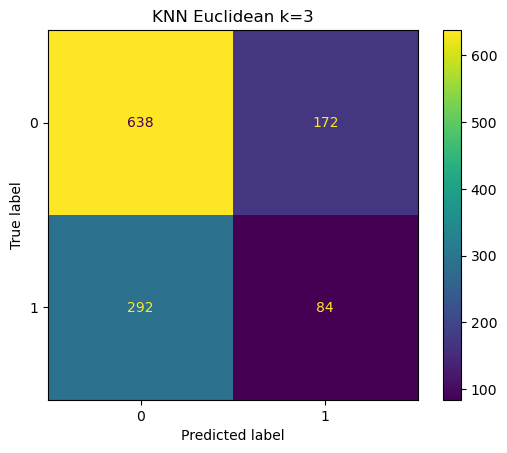

Fitting KNN Euclidean with k=5

KNN Euclidean k=5
              precision    recall  f1-score   support

           0       0.68      0.83      0.75       810
           1       0.33      0.18      0.23       376

    accuracy                           0.62      1186
   macro avg       0.50      0.50      0.49      1186
weighted avg       0.57      0.62      0.58      1186



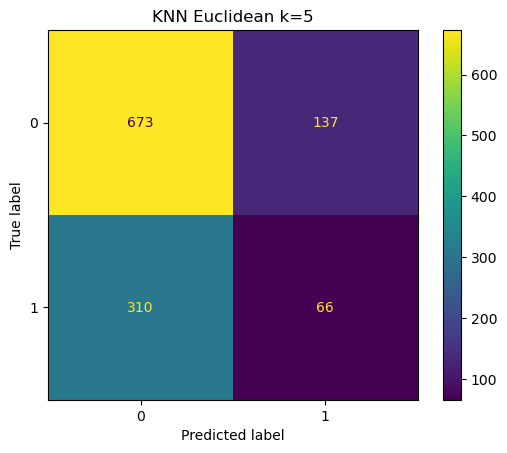

Fitting KNN Euclidean with k=7

KNN Euclidean k=7
              precision    recall  f1-score   support

           0       0.68      0.85      0.76       810
           1       0.32      0.15      0.21       376

    accuracy                           0.63      1186
   macro avg       0.50      0.50      0.48      1186
weighted avg       0.57      0.63      0.58      1186



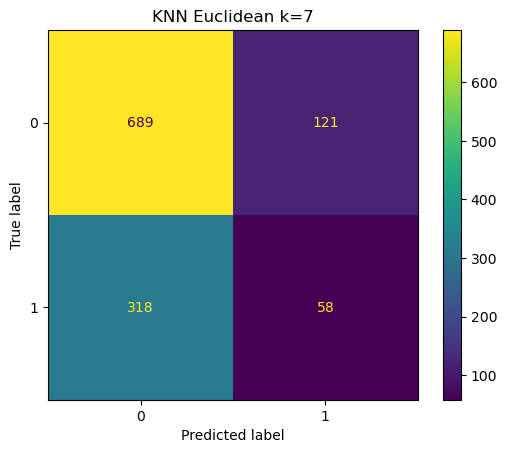

Fitting KNN Euclidean with k=9

KNN Euclidean k=9
              precision    recall  f1-score   support

           0       0.69      0.86      0.77       810
           1       0.36      0.16      0.22       376

    accuracy                           0.64      1186
   macro avg       0.52      0.51      0.50      1186
weighted avg       0.58      0.64      0.59      1186



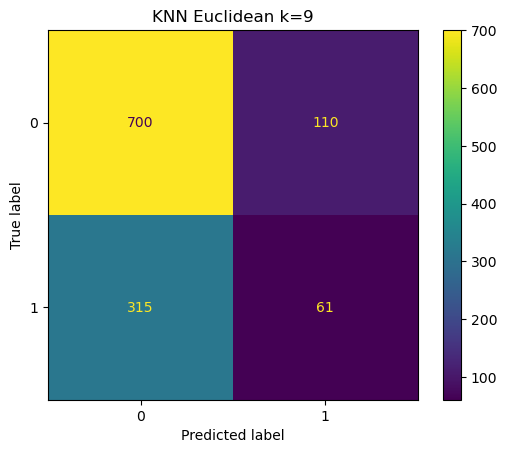

Fitting KNN Euclidean with k=11

KNN Euclidean k=11
              precision    recall  f1-score   support

           0       0.69      0.88      0.77       810
           1       0.36      0.15      0.21       376

    accuracy                           0.65      1186
   macro avg       0.52      0.51      0.49      1186
weighted avg       0.58      0.65      0.59      1186



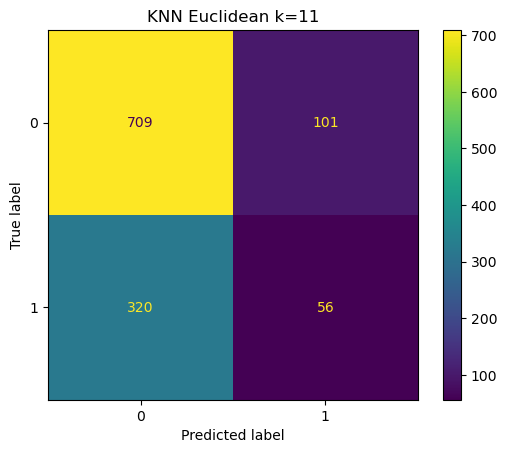

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc,n_neighbors,distance
4,KNN Euclidean k=9,0.641653,0.513216,0.523190,0.513216,0.495079,0.584106,0.641653,0.594630,0.499168,9,euclidean
5,KNN Euclidean k=11,0.645025,0.512122,0.522853,0.512122,0.490601,0.583659,0.645025,0.593235,0.509151,11,euclidean
1,KNN Euclidean k=3,0.608769,0.505529,0.507073,0.505529,0.499578,0.572557,0.608769,0.585118,0.506797,3,euclidean
2,KNN Euclidean k=5,0.623103,0.503198,0.504881,0.503198,0.489338,0.570661,0.623103,0.584979,0.502586,5,euclidean
3,KNN Euclidean k=7,0.629848,0.502436,0.504116,0.502436,0.483701,0.570019,0.629848,0.584221,0.502318,7,euclidean
0,KNN Euclidean k=1,0.566610,0.487490,0.486801,0.487490,0.486680,0.555800,0.566610,0.560804,0.487490,1,euclidean


In [12]:
# KNN with Euclidean distance

from sklearn.neighbors import KNeighborsClassifier

knn_euclidean_results = []

for n_neighbors in [1, 3, 5, 7, 9, 11]:
    print(f"Fitting KNN Euclidean with k={n_neighbors}")

    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric="euclidean",
        weights="distance"
    )

    model.fit(X_train_flat, y_train)
    y_pred = model.predict(X_test_flat)
    y_score = model.predict_proba(X_test_flat)[:, 1]

    result = evaluate_classifier(
        model_name=f"KNN Euclidean k={n_neighbors}",
        y_true=y_test,
        y_pred=y_pred,
        y_score=y_score
    )

    result["n_neighbors"] = n_neighbors
    result["distance"] = "euclidean"
    knn_euclidean_results.append(result)

knn_euclidean_results_df = pd.DataFrame(knn_euclidean_results)

display(
    knn_euclidean_results_df
    .sort_values("balanced_accuracy", ascending=False)
)

Fitting KNN Manhattan with k=1

KNN Manhattan k=1
              precision    recall  f1-score   support

           0       0.68      0.73      0.70       810
           1       0.32      0.27      0.29       376

    accuracy                           0.58      1186
   macro avg       0.50      0.50      0.50      1186
weighted avg       0.57      0.58      0.57      1186



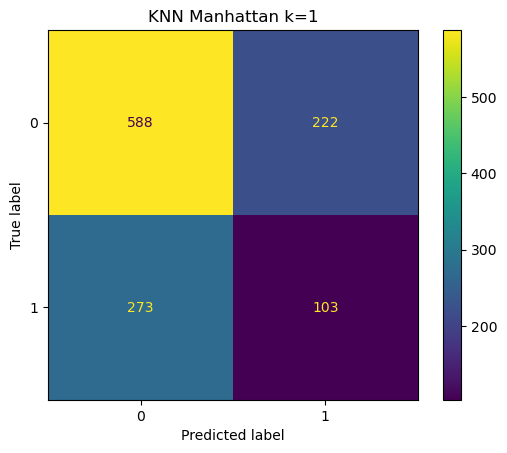

Fitting KNN Manhattan with k=3

KNN Manhattan k=3
              precision    recall  f1-score   support

           0       0.67      0.77      0.72       810
           1       0.29      0.20      0.23       376

    accuracy                           0.59      1186
   macro avg       0.48      0.48      0.48      1186
weighted avg       0.55      0.59      0.56      1186



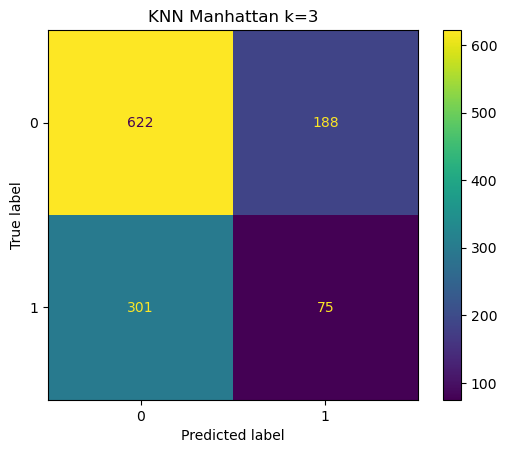

Fitting KNN Manhattan with k=5

KNN Manhattan k=5
              precision    recall  f1-score   support

           0       0.68      0.82      0.74       810
           1       0.32      0.18      0.23       376

    accuracy                           0.62      1186
   macro avg       0.50      0.50      0.49      1186
weighted avg       0.57      0.62      0.58      1186



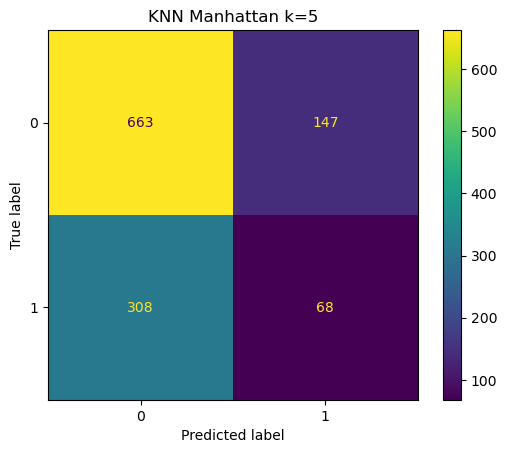

Fitting KNN Manhattan with k=7

KNN Manhattan k=7
              precision    recall  f1-score   support

           0       0.68      0.85      0.76       810
           1       0.32      0.16      0.21       376

    accuracy                           0.63      1186
   macro avg       0.50      0.50      0.48      1186
weighted avg       0.57      0.63      0.58      1186



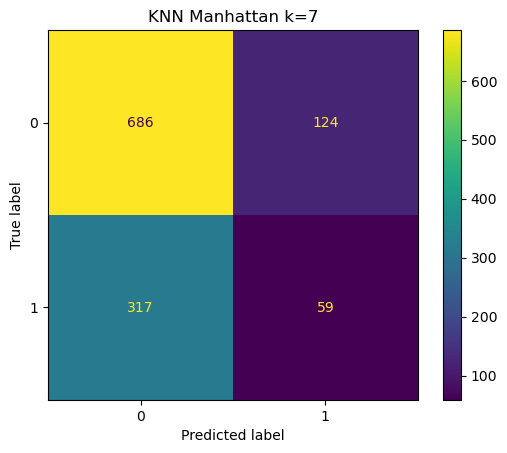

Fitting KNN Manhattan with k=9

KNN Manhattan k=9
              precision    recall  f1-score   support

           0       0.68      0.86      0.76       810
           1       0.28      0.11      0.16       376

    accuracy                           0.63      1186
   macro avg       0.48      0.49      0.46      1186
weighted avg       0.55      0.63      0.57      1186



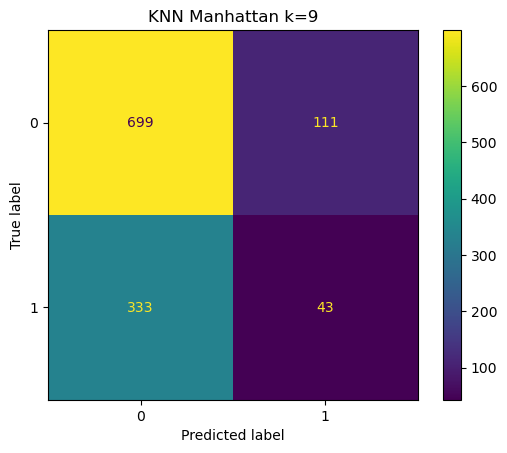

Fitting KNN Manhattan with k=11

KNN Manhattan k=11
              precision    recall  f1-score   support

           0       0.68      0.88      0.77       810
           1       0.29      0.10      0.15       376

    accuracy                           0.64      1186
   macro avg       0.49      0.49      0.46      1186
weighted avg       0.56      0.64      0.57      1186



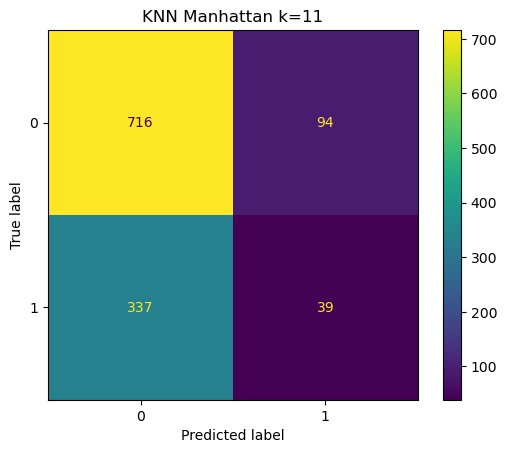

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc,n_neighbors,distance
3,KNN Manhattan k=7,0.628162,0.501914,0.503176,0.501914,0.483924,0.569327,0.628162,0.583763,0.489903,7,manhattan
0,KNN Manhattan k=1,0.582631,0.499931,0.499925,0.499931,0.498818,0.566892,0.582631,0.573817,0.499931,1,manhattan
2,KNN Manhattan k=5,0.616358,0.499685,0.499540,0.499685,0.487322,0.566602,0.616358,0.581442,0.486893,5,manhattan
5,KNN Manhattan k=11,0.636594,0.493837,0.486598,0.493837,0.460947,0.557357,0.636594,0.573548,0.495840,11,manhattan
4,KNN Manhattan k=9,0.625632,0.488662,0.478273,0.488662,0.460611,0.551114,0.625632,0.569787,0.492479,9,manhattan
1,KNN Manhattan k=3,0.587690,0.483685,0.479530,0.483685,0.476286,0.550653,0.587690,0.564676,0.489562,3,manhattan


In [13]:
# KNN with Manhattan distance

knn_manhattan_results = []

for n_neighbors in [1, 3, 5, 7, 9, 11]:
    print(f"Fitting KNN Manhattan with k={n_neighbors}")

    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric="manhattan",
        weights="distance"
    )

    model.fit(X_train_flat, y_train)
    y_pred = model.predict(X_test_flat)
    y_score = model.predict_proba(X_test_flat)[:, 1]

    result = evaluate_classifier(
        model_name=f"KNN Manhattan k={n_neighbors}",
        y_true=y_test,
        y_pred=y_pred,
        y_score=y_score
    )

    result["n_neighbors"] = n_neighbors
    result["distance"] = "manhattan"
    knn_manhattan_results.append(result)

knn_manhattan_results_df = pd.DataFrame(knn_manhattan_results)

display(
    knn_manhattan_results_df
    .sort_values("balanced_accuracy", ascending=False)
)

Fitting KNN DTW with k=1

KNN DTW k=1
              precision    recall  f1-score   support

           0       0.68      0.71      0.69       810
           1       0.31      0.28      0.30       376

    accuracy                           0.57      1186
   macro avg       0.50      0.50      0.49      1186
weighted avg       0.56      0.57      0.57      1186



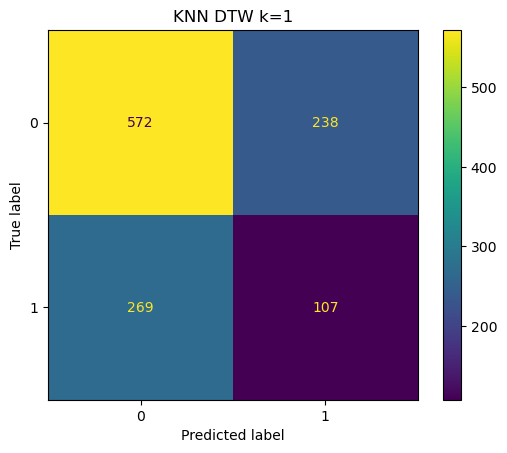

Fitting KNN DTW with k=3

KNN DTW k=3
              precision    recall  f1-score   support

           0       0.69      0.76      0.72       810
           1       0.33      0.25      0.28       376

    accuracy                           0.60      1186
   macro avg       0.51      0.51      0.50      1186
weighted avg       0.57      0.60      0.58      1186



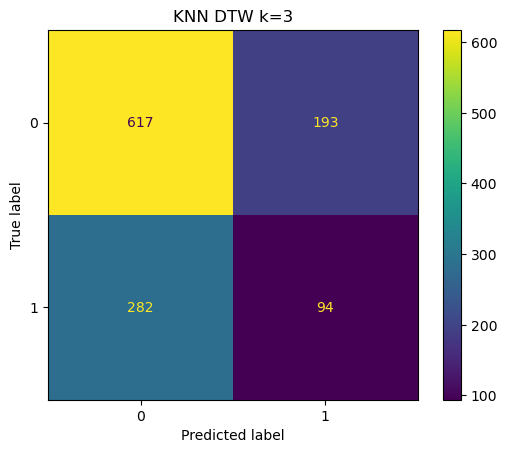

Fitting KNN DTW with k=5

KNN DTW k=5
              precision    recall  f1-score   support

           0       0.68      0.78      0.72       810
           1       0.29      0.19      0.23       376

    accuracy                           0.59      1186
   macro avg       0.48      0.49      0.48      1186
weighted avg       0.55      0.59      0.57      1186



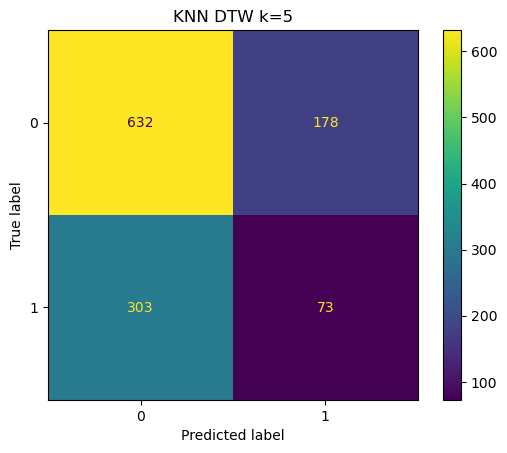

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,n_neighbors,distance
1,KNN DTW k=3,0.599494,0.505864,0.506922,0.505864,0.502810,0.572570,0.599494,0.583041,3,dtw
0,KNN DTW k=1,0.572513,0.495374,0.495144,0.495374,0.494862,0.562842,0.572513,0.567336,1,dtw
2,KNN DTW k=5,0.594435,0.487198,0.483386,0.487198,0.478605,0.553847,0.594435,0.568534,5,dtw


In [14]:
# KNN with DTW distance

from tslearn.neighbors import KNeighborsTimeSeriesClassifier

knn_dtw_results = []

for n_neighbors in [1, 3, 5]:
    print(f"Fitting KNN DTW with k={n_neighbors}")

    model = KNeighborsTimeSeriesClassifier(
        n_neighbors=n_neighbors,
        metric="dtw",
        weights="distance",
        n_jobs=-1
    )

    model.fit(X_train_ts, y_train)
    y_pred = model.predict(X_test_ts)

    result = evaluate_classifier(
        model_name=f"KNN DTW k={n_neighbors}",
        y_true=y_test,
        y_pred=y_pred
    )

    result["n_neighbors"] = n_neighbors
    result["distance"] = "dtw"
    knn_dtw_results.append(result)

knn_dtw_results_df = pd.DataFrame(knn_dtw_results)

display(
    knn_dtw_results_df
    .sort_values("balanced_accuracy", ascending=False)
)

Fitting KNN Sakoe-Chiba DTW with k=1

KNN Sakoe-Chiba DTW k=1
              precision    recall  f1-score   support

           0       0.67      0.70      0.69       810
           1       0.29      0.27      0.28       376

    accuracy                           0.56      1186
   macro avg       0.48      0.48      0.48      1186
weighted avg       0.55      0.56      0.56      1186



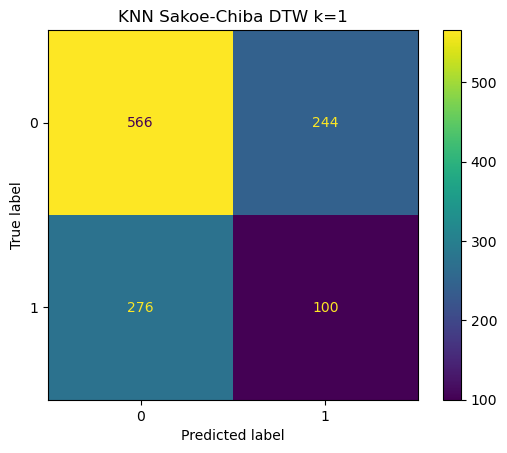

Fitting KNN Sakoe-Chiba DTW with k=3

KNN Sakoe-Chiba DTW k=3
              precision    recall  f1-score   support

           0       0.68      0.76      0.72       810
           1       0.31      0.23      0.26       376

    accuracy                           0.59      1186
   macro avg       0.49      0.49      0.49      1186
weighted avg       0.56      0.59      0.57      1186



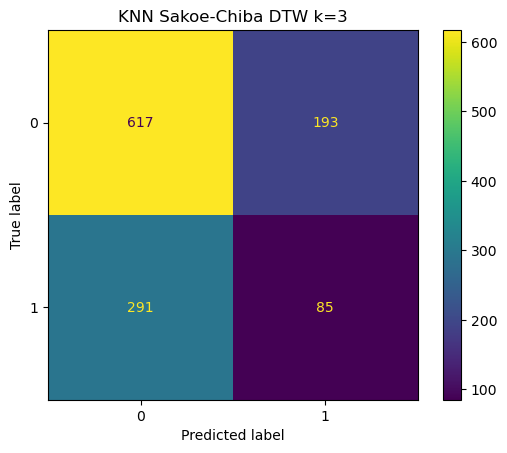

Fitting KNN Sakoe-Chiba DTW with k=5

KNN Sakoe-Chiba DTW k=5
              precision    recall  f1-score   support

           0       0.67      0.79      0.72       810
           1       0.27      0.17      0.21       376

    accuracy                           0.59      1186
   macro avg       0.47      0.48      0.46      1186
weighted avg       0.54      0.59      0.56      1186



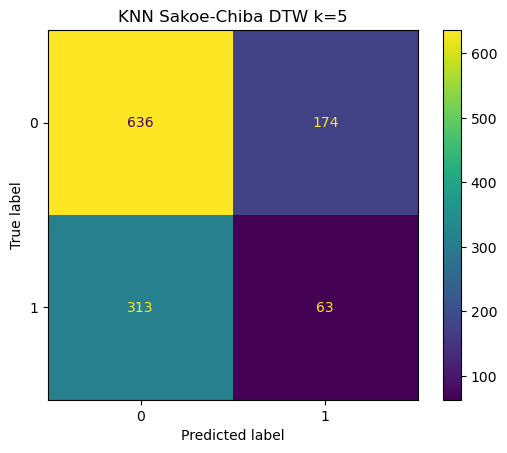

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,n_neighbors,distance,sakoe_radius
1,KNN Sakoe-Chiba DTW k=3,0.591906,0.493896,0.492635,0.493896,0.489108,0.561022,0.591906,0.572969,3,sakoe_chiba_dtw,4
0,KNN Sakoe-Chiba DTW k=1,0.561551,0.482361,0.481453,0.482361,0.481504,0.551258,0.561551,0.556055,1,sakoe_chiba_dtw,4
2,KNN Sakoe-Chiba DTW k=5,0.589376,0.476369,0.468001,0.476369,0.464342,0.541985,0.589376,0.559045,5,sakoe_chiba_dtw,4


In [15]:
# KNN with Sakoe-Chiba constrained DTW

knn_sakoe_results = []
sakoe_radius = 4

for n_neighbors in [1, 3, 5]:
    print(f"Fitting KNN Sakoe-Chiba DTW with k={n_neighbors}")

    model = KNeighborsTimeSeriesClassifier(
        n_neighbors=n_neighbors,
        metric="dtw",
        metric_params={
            "sakoe_chiba_radius": sakoe_radius
        },
        weights="distance",
        n_jobs=-1
    )

    model.fit(X_train_ts, y_train)
    y_pred = model.predict(X_test_ts)

    result = evaluate_classifier(
        model_name=f"KNN Sakoe-Chiba DTW k={n_neighbors}",
        y_true=y_test,
        y_pred=y_pred
    )

    result["n_neighbors"] = n_neighbors
    result["distance"] = "sakoe_chiba_dtw"
    result["sakoe_radius"] = sakoe_radius
    knn_sakoe_results.append(result)

knn_sakoe_results_df = pd.DataFrame(knn_sakoe_results)

display(
    knn_sakoe_results_df
    .sort_values("balanced_accuracy", ascending=False)
)

In [16]:
# Combine KNN results into one comparison table

knn_results_df = pd.concat(
    [
        knn_euclidean_results_df,
        knn_manhattan_results_df,
        knn_dtw_results_df,
        knn_sakoe_results_df
    ],
    ignore_index=True
)

display(
    knn_results_df
    .sort_values("balanced_accuracy", ascending=False)
    [
        [
            "model",
            "distance",
            "n_neighbors",
            "accuracy",
            "balanced_accuracy",
            "precision_macro",
            "recall_macro",
            "f1_macro",
            "f1_weighted"
        ]
    ]
)

,model,distance,n_neighbors,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
4,KNN Euclidean k=9,euclidean,9,0.641653,0.513216,0.523190,0.513216,0.495079,0.594630
5,KNN Euclidean k=11,euclidean,11,0.645025,0.512122,0.522853,0.512122,0.490601,0.593235
13,KNN DTW k=3,dtw,3,0.599494,0.505864,0.506922,0.505864,0.502810,0.583041
1,KNN Euclidean k=3,euclidean,3,0.608769,0.505529,0.507073,0.505529,0.499578,0.585118
2,KNN Euclidean k=5,euclidean,5,0.623103,0.503198,0.504881,0.503198,0.489338,0.584979
3,KNN Euclidean k=7,euclidean,7,0.629848,0.502436,0.504116,0.502436,0.483701,0.584221
9,KNN Manhattan k=7,manhattan,7,0.628162,0.501914,0.503176,0.501914,0.483924,0.583763
6,KNN Manhattan k=1,manhattan,1,0.582631,0.499931,0.499925,0.499931,0.498818,0.573817
8,KNN Manhattan k=5,manhattan,5,0.616358,0.499685,0.499540,0.499685,0.487322,0.581442
12,KNN DTW k=1,dtw,1,0.572513,0.495374,0.495144,0.495374,0.494862,0.567336


Fitting DummyClassifier with strategy=most_frequent

DummyClassifier (most_frequent)
              precision    recall  f1-score   support

           0       0.68      1.00      0.81       810
           1       0.00      0.00      0.00       376

    accuracy                           0.68      1186
   macro avg       0.34      0.50      0.41      1186
weighted avg       0.47      0.68      0.55      1186



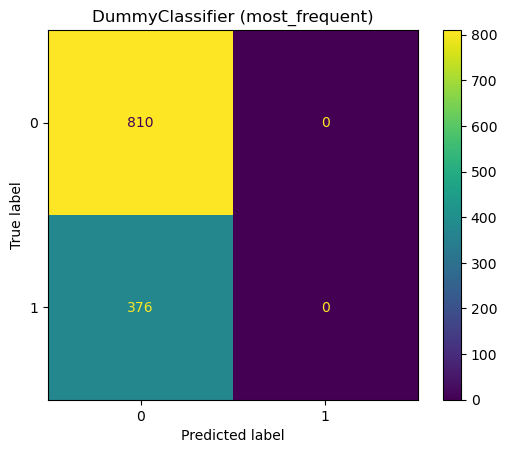

Fitting DummyClassifier with strategy=stratified

DummyClassifier (stratified)
              precision    recall  f1-score   support

           0       0.69      0.67      0.68       810
           1       0.32      0.34      0.33       376

    accuracy                           0.56      1186
   macro avg       0.50      0.50      0.50      1186
weighted avg       0.57      0.56      0.57      1186



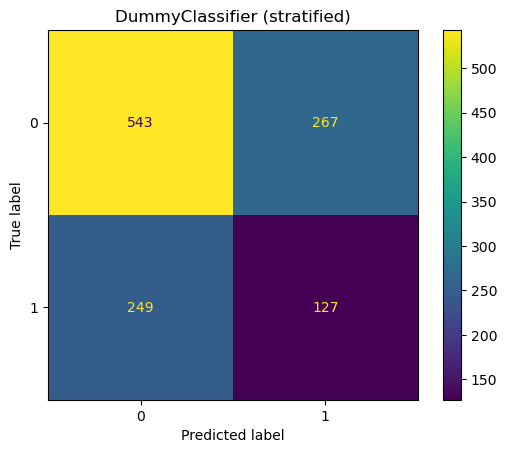

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc
0,DummyClassifier (most_frequent),0.682968,0.500000,0.341484,0.500000,0.405812,0.554313,0.500000
1,DummyClassifier (stratified),0.564924,0.504068,0.503971,0.504068,0.503886,0.567565,0.504068


In [17]:
# Dummy baseline classifiers

from sklearn.dummy import DummyClassifier

dummy_results = []

for strategy in ["most_frequent", "stratified"]:
    print(f"Fitting DummyClassifier with strategy={strategy}")

    dummy = DummyClassifier(
        strategy=strategy,
        random_state=random_state
    )

    dummy.fit(X_train_flat, y_train)
    y_pred_dummy = dummy.predict(X_test_flat)

    if hasattr(dummy, "predict_proba"):
        y_score_dummy = dummy.predict_proba(X_test_flat)[:, 1]
    else:
        y_score_dummy = None

    result = evaluate_classifier(
        model_name=f"DummyClassifier ({strategy})",
        y_true=y_test,
        y_pred=y_pred_dummy,
        y_score=y_score_dummy
    )

    result["strategy"] = strategy
    dummy_results.append(result)

dummy_results_df = pd.DataFrame(dummy_results)

display(
    dummy_results_df[
        [
            "model",
            "accuracy",
            "balanced_accuracy",
            "precision_macro",
            "recall_macro",
            "f1_macro",
            "f1_weighted",
            "roc_auc"
        ]
    ]
)

## Shaplets

Original X_train_ts shape: (3124, 50, 6)
Shapelet input shape: (3124, 6, 50)
Series length seen by shapelet transformer: 50
Fitting RandomShapeletTransform...
Shapelet train feature matrix: (3124, 20)
Shapelet test feature matrix: (1186, 20)
Fitting classifier on shapelet features...

Random Shapelet Transform + Random Forest
              precision    recall  f1-score   support

           0       0.68      0.92      0.79       810
           1       0.33      0.08      0.13       376

    accuracy                           0.66      1186
   macro avg       0.50      0.50      0.46      1186
weighted avg       0.57      0.66      0.58      1186



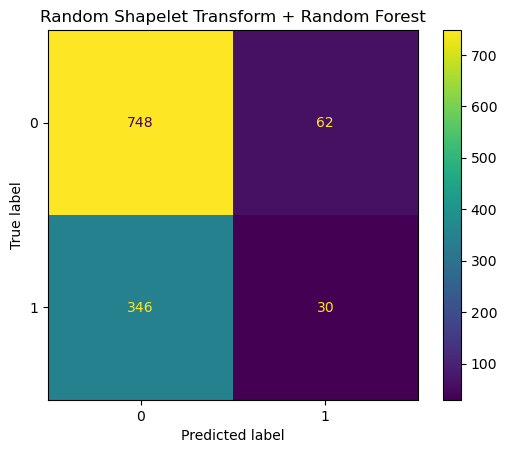

In [19]:
# Shapelet-based classification using RandomShapeletTransform
# Correct input orientation for sktime: n_instances × n_channels × n_timepoints

from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform
from sklearn.ensemble import RandomForestClassifier

# Convert from (n_instances, n_timepoints, n_channels) to (n_instances, n_channels, n_timepoints)
X_train_shapelet_input = np.transpose(X_train_ts, (0, 2, 1))
X_test_shapelet_input = np.transpose(X_test_ts, (0, 2, 1))

print("Original X_train_ts shape:", X_train_ts.shape)
print("Shapelet input shape:", X_train_shapelet_input.shape)

# Safety check
series_length_for_shapelets = X_train_shapelet_input.shape[2]
print("Series length seen by shapelet transformer:", series_length_for_shapelets)

shapelet_transformer = RandomShapeletTransform(
    n_shapelet_samples=1000,
    max_shapelets=20,
    min_shapelet_length=4,
    max_shapelet_length=min(16, series_length_for_shapelets - 1),
    random_state=random_state,
    n_jobs=-1
)

shapelet_classifier = RandomForestClassifier(
    n_estimators=300,
    random_state=random_state,
    class_weight="balanced",
    n_jobs=-1
)

print("Fitting RandomShapeletTransform...")
X_train_shapelet = shapelet_transformer.fit_transform(
    X_train_shapelet_input,
    y_train
)

X_test_shapelet = shapelet_transformer.transform(
    X_test_shapelet_input
)

print("Shapelet train feature matrix:", X_train_shapelet.shape)
print("Shapelet test feature matrix:", X_test_shapelet.shape)

print("Fitting classifier on shapelet features...")
shapelet_classifier.fit(X_train_shapelet, y_train)

y_pred_shapelet = shapelet_classifier.predict(X_test_shapelet)

if hasattr(shapelet_classifier, "predict_proba"):
    y_score_shapelet = shapelet_classifier.predict_proba(X_test_shapelet)[:, 1]
else:
    y_score_shapelet = None

shapelet_result = evaluate_classifier(
    model_name="Random Shapelet Transform + Random Forest",
    y_true=y_test,
    y_pred=y_pred_shapelet,
    y_score=y_score_shapelet
)

shapelet_result["method_family"] = "shapelet"
shapelet_result["representation"] = "global-scaled multivariate PAA"

In [20]:
# Check class imbalance in full dataset, train set and test set

def class_distribution_table(y_array, name):
    counts = pd.Series(y_array).value_counts().sort_index()
    percentages = (counts / counts.sum() * 100).round(2)

    return pd.DataFrame({
        "split": name,
        "class": counts.index,
        "n": counts.values,
        "percentage": percentages.values
    })


imbalance_df = pd.concat(
    [
        class_distribution_table(y, "Full dataset"),
        class_distribution_table(y_train, "Train"),
        class_distribution_table(y_test, "Test")
    ],
    ignore_index=True
)

display(imbalance_df)

# Compact pivot version
imbalance_pivot = imbalance_df.pivot(
    index="split",
    columns="class",
    values=["n", "percentage"]
)

display(imbalance_pivot)

,split,class,n,percentage
0,Full dataset,0,2888,67.01
1,Full dataset,1,1422,32.99
2,Train,0,2078,66.52
3,Train,1,1046,33.48
4,Test,0,810,68.30
5,Test,1,376,31.70


n         percentage       
class              0       1          0      1
split                                         
Full dataset  2888.0  1422.0      67.01  32.99
Test           810.0   376.0      68.30  31.70
Train         2078.0  1046.0      66.52  33.48

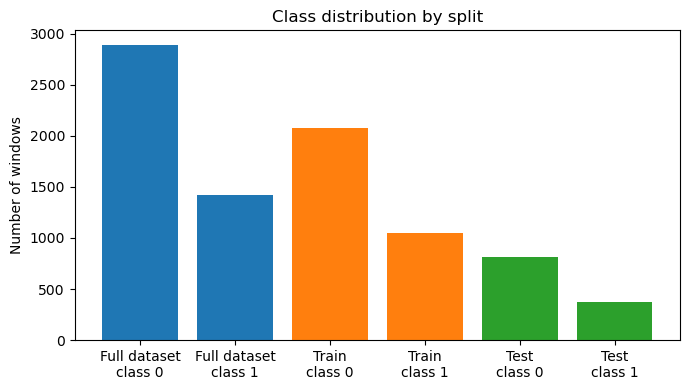

In [21]:
# Plot class distribution by split

plot_df = imbalance_df.copy()

plt.figure(figsize=(7, 4))

for split in plot_df["split"].unique():
    subset = plot_df[plot_df["split"] == split]
    plt.bar(
        [f"{split}\nclass {cls}" for cls in subset["class"]],
        subset["n"]
    )

plt.ylabel("Number of windows")
plt.title("Class distribution by split")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
# Random oversampling of minority class in the training set only

from sklearn.utils import resample

def random_oversample_timeseries(X_ts, y, groups=None, random_state=42):
    """
    Randomly oversample minority-class time-series windows in the training set.

    Parameters
    ----------
    X_ts : np.ndarray
        Shape: n_instances × n_timepoints × n_channels
        or n_instances × n_channels × n_timepoints.
    y : np.ndarray
        Class labels.
    groups : np.ndarray or None
        Subject IDs. These are resampled together with X and y only for traceability.
    random_state : int
        Random seed.

    Returns
    -------
    X_res : np.ndarray
    y_res : np.ndarray
    groups_res : np.ndarray or None
    """

    y_series = pd.Series(y)
    class_counts = y_series.value_counts()
    majority_class = class_counts.idxmax()
    minority_class = class_counts.idxmin()

    majority_idx = np.where(y == majority_class)[0]
    minority_idx = np.where(y == minority_class)[0]

    minority_idx_upsampled = resample(
        minority_idx,
        replace=True,
        n_samples=len(majority_idx),
        random_state=random_state
    )

    resampled_idx = np.concatenate([majority_idx, minority_idx_upsampled])

    rng = np.random.default_rng(random_state)
    rng.shuffle(resampled_idx)

    X_res = X_ts[resampled_idx]
    y_res = y[resampled_idx]

    if groups is not None:
        groups_res = groups[resampled_idx]
    else:
        groups_res = None

    return X_res, y_res, groups_res


X_train_ts_os, y_train_os, groups_train_os = random_oversample_timeseries(
    X_ts=X_train_ts,
    y=y_train,
    groups=groups_train,
    random_state=random_state
)

X_train_subject_ts_os, _, _ = random_oversample_timeseries(
    X_ts=X_train_subject_ts,
    y=y_train,
    groups=groups_train,
    random_state=random_state
)

print("Original train distribution:")
display(pd.Series(y_train).value_counts().sort_index())

print("Oversampled train distribution:")
display(pd.Series(y_train_os).value_counts().sort_index())

print("Original train shape:", X_train_ts.shape)
print("Oversampled train shape:", X_train_ts_os.shape)

Original train distribution:


0    2078
1    1046
Name: count, dtype: int64

Oversampled train distribution:


0    2078
1    2078
Name: count, dtype: int64

Original train shape: (3124, 50, 6)
Oversampled train shape: (4156, 50, 6)


In [23]:
# Flatten oversampled training representation

X_train_flat_os = X_train_ts_os.reshape(X_train_ts_os.shape[0], -1)

print("X_train_flat_os shape:", X_train_flat_os.shape)
print("X_test_flat shape:", X_test_flat.shape)

X_train_flat_os shape: (4156, 300)
X_test_flat shape: (1186, 300)


Fitting KNN Euclidean + oversampling with k=1

KNN Euclidean + ROS k=1
              precision    recall  f1-score   support

           0       0.67      0.73      0.70       810
           1       0.28      0.22      0.25       376

    accuracy                           0.57      1186
   macro avg       0.48      0.48      0.48      1186
weighted avg       0.55      0.57      0.56      1186



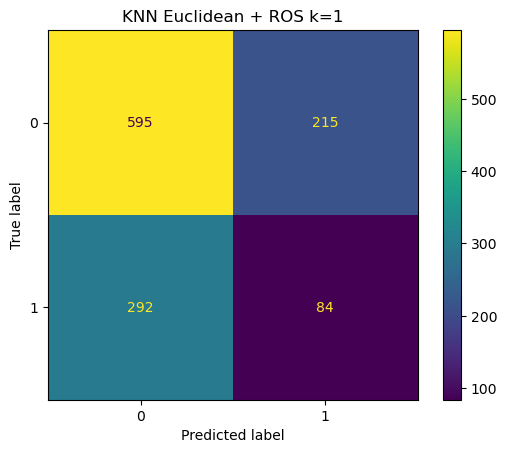

Fitting KNN Euclidean + oversampling with k=3

KNN Euclidean + ROS k=3
              precision    recall  f1-score   support

           0       0.68      0.67      0.68       810
           1       0.32      0.34      0.33       376

    accuracy                           0.56      1186
   macro avg       0.50      0.50      0.50      1186
weighted avg       0.57      0.56      0.57      1186



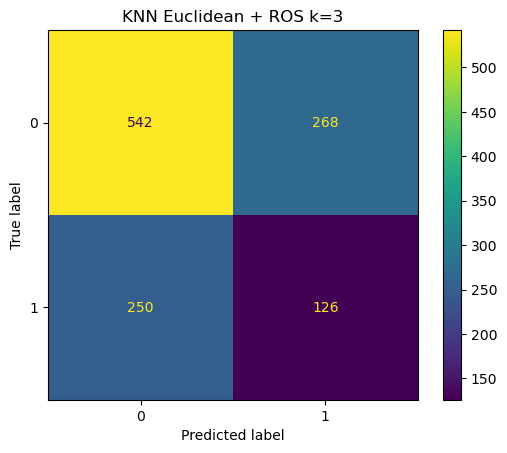

Fitting KNN Euclidean + oversampling with k=5

KNN Euclidean + ROS k=5
              precision    recall  f1-score   support

           0       0.69      0.67      0.68       810
           1       0.33      0.36      0.34       376

    accuracy                           0.57      1186
   macro avg       0.51      0.51      0.51      1186
weighted avg       0.58      0.57      0.57      1186



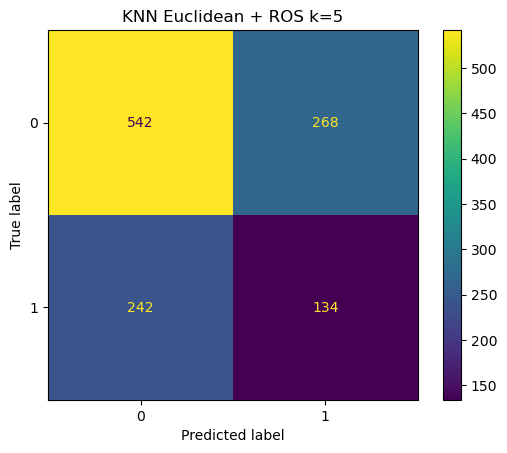

Fitting KNN Euclidean + oversampling with k=7

KNN Euclidean + ROS k=7
              precision    recall  f1-score   support

           0       0.69      0.66      0.67       810
           1       0.33      0.35      0.34       376

    accuracy                           0.56      1186
   macro avg       0.51      0.51      0.51      1186
weighted avg       0.57      0.56      0.57      1186



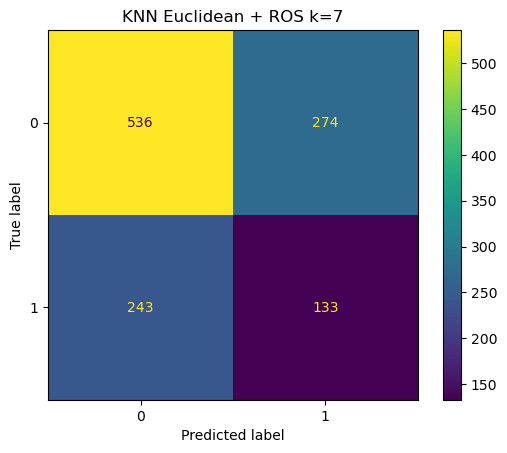

Fitting KNN Euclidean + oversampling with k=9

KNN Euclidean + ROS k=9
              precision    recall  f1-score   support

           0       0.69      0.66      0.68       810
           1       0.33      0.36      0.35       376

    accuracy                           0.57      1186
   macro avg       0.51      0.51      0.51      1186
weighted avg       0.58      0.57      0.57      1186



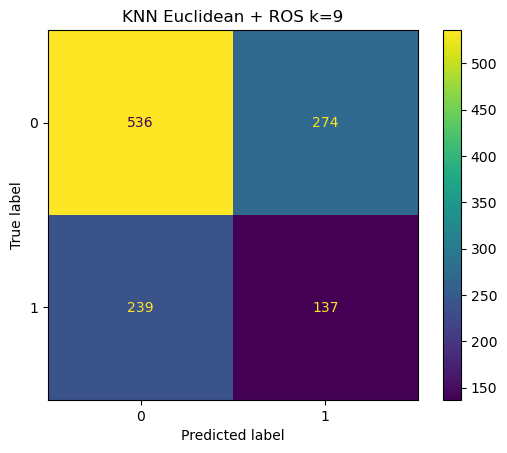

Fitting KNN Euclidean + oversampling with k=11

KNN Euclidean + ROS k=11
              precision    recall  f1-score   support

           0       0.69      0.66      0.68       810
           1       0.33      0.36      0.34       376

    accuracy                           0.57      1186
   macro avg       0.51      0.51      0.51      1186
weighted avg       0.58      0.57      0.57      1186



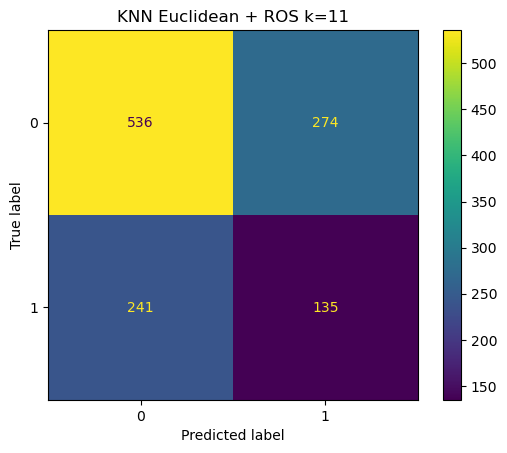

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc,n_neighbors,distance,imbalance_strategy
4,KNN Euclidean + ROS k=9,0.567454,0.513045,0.512473,0.513045,0.512249,0.578027,0.567454,0.572296,0.509133,9,euclidean,random_oversampling
2,KNN Euclidean + ROS k=5,0.569983,0.512759,0.512330,0.512759,0.512262,0.577831,0.569983,0.573661,0.505372,5,euclidean,random_oversampling
5,KNN Euclidean + ROS k=11,0.565767,0.510385,0.509953,0.510385,0.509719,0.575777,0.565767,0.570380,0.513107,11,euclidean,random_oversampling
3,KNN Euclidean + ROS k=7,0.564081,0.507726,0.507421,0.507726,0.507179,0.573524,0.564081,0.568458,0.508908,7,euclidean,random_oversampling
1,KNN Euclidean + ROS k=3,0.563238,0.502121,0.502070,0.502121,0.501963,0.568771,0.563238,0.565889,0.503241,3,euclidean,random_oversampling
0,KNN Euclidean + ROS k=1,0.572513,0.478986,0.475868,0.478986,0.475063,0.547201,0.572513,0.557828,0.478986,1,euclidean,random_oversampling


In [24]:
# KNN Euclidean with random oversampling

knn_euclidean_os_results = []

for n_neighbors in [1, 3, 5, 7, 9, 11]:
    print(f"Fitting KNN Euclidean + oversampling with k={n_neighbors}")

    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric="euclidean",
        weights="distance"
    )

    model.fit(X_train_flat_os, y_train_os)
    y_pred = model.predict(X_test_flat)
    y_score = model.predict_proba(X_test_flat)[:, 1]

    result = evaluate_classifier(
        model_name=f"KNN Euclidean + ROS k={n_neighbors}",
        y_true=y_test,
        y_pred=y_pred,
        y_score=y_score
    )

    result["n_neighbors"] = n_neighbors
    result["distance"] = "euclidean"
    result["imbalance_strategy"] = "random_oversampling"
    knn_euclidean_os_results.append(result)

knn_euclidean_os_results_df = pd.DataFrame(knn_euclidean_os_results)

display(
    knn_euclidean_os_results_df
    .sort_values("balanced_accuracy", ascending=False)
)

Fitting KNN Manhattan + oversampling with k=1

KNN Manhattan + ROS k=1
              precision    recall  f1-score   support

           0       0.68      0.76      0.72       810
           1       0.30      0.23      0.26       376

    accuracy                           0.59      1186
   macro avg       0.49      0.49      0.49      1186
weighted avg       0.56      0.59      0.57      1186



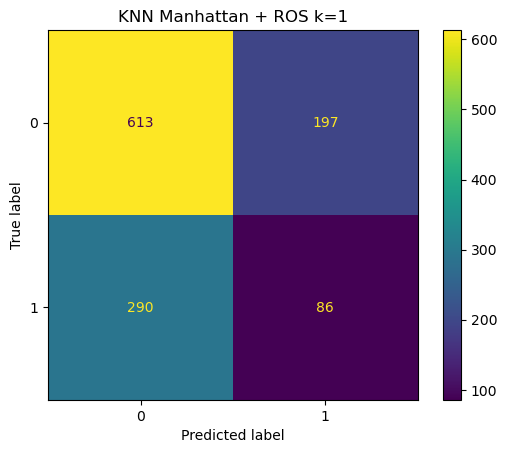

Fitting KNN Manhattan + oversampling with k=3

KNN Manhattan + ROS k=3
              precision    recall  f1-score   support

           0       0.68      0.69      0.69       810
           1       0.30      0.29      0.30       376

    accuracy                           0.56      1186
   macro avg       0.49      0.49      0.49      1186
weighted avg       0.56      0.56      0.56      1186



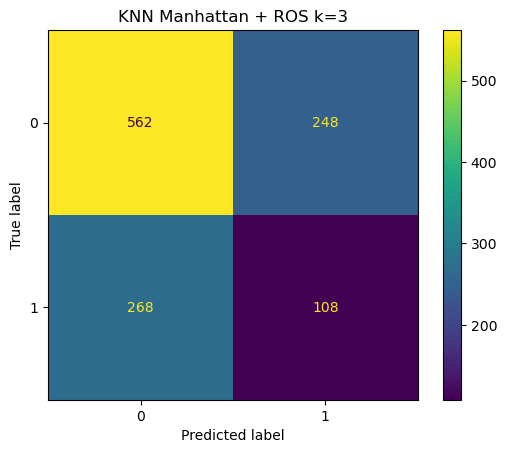

Fitting KNN Manhattan + oversampling with k=5

KNN Manhattan + ROS k=5
              precision    recall  f1-score   support

           0       0.69      0.69      0.69       810
           1       0.34      0.34      0.34       376

    accuracy                           0.58      1186
   macro avg       0.52      0.52      0.52      1186
weighted avg       0.58      0.58      0.58      1186



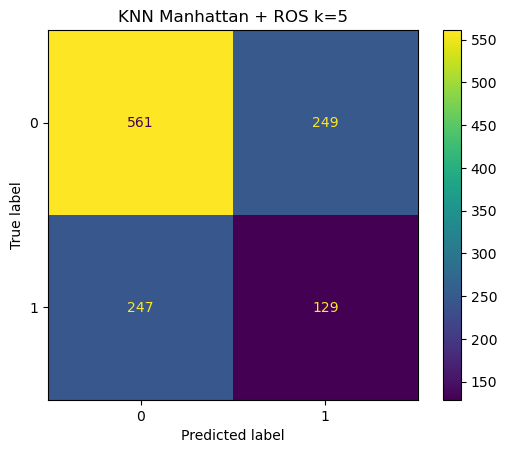

Fitting KNN Manhattan + oversampling with k=7

KNN Manhattan + ROS k=7
              precision    recall  f1-score   support

           0       0.69      0.69      0.69       810
           1       0.33      0.33      0.33       376

    accuracy                           0.57      1186
   macro avg       0.51      0.51      0.51      1186
weighted avg       0.57      0.57      0.57      1186



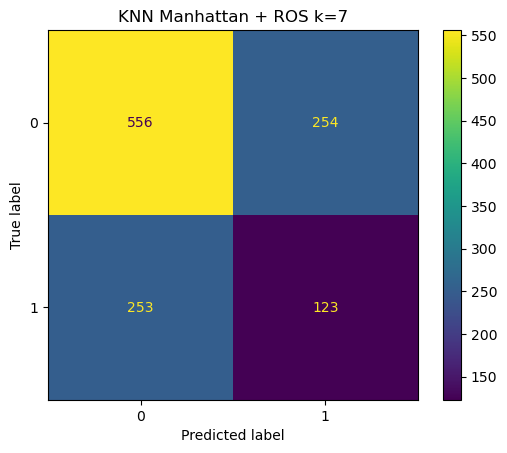

Fitting KNN Manhattan + oversampling with k=9

KNN Manhattan + ROS k=9
              precision    recall  f1-score   support

           0       0.69      0.68      0.68       810
           1       0.33      0.33      0.33       376

    accuracy                           0.57      1186
   macro avg       0.51      0.51      0.51      1186
weighted avg       0.57      0.57      0.57      1186



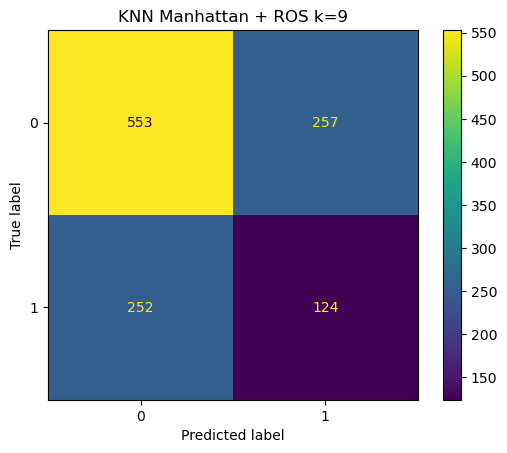

Fitting KNN Manhattan + oversampling with k=11

KNN Manhattan + ROS k=11
              precision    recall  f1-score   support

           0       0.70      0.70      0.70       810
           1       0.35      0.35      0.35       376

    accuracy                           0.59      1186
   macro avg       0.52      0.52      0.52      1186
weighted avg       0.59      0.59      0.59      1186



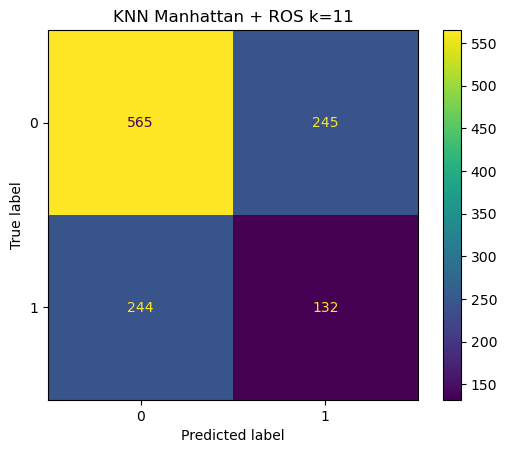

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc,n_neighbors,distance,imbalance_strategy
5,KNN Manhattan + ROS k=11,0.587690,0.524297,0.524263,0.524297,0.524280,0.587983,0.587690,0.587836,0.517744,11,manhattan,random_oversampling
2,KNN Manhattan + ROS k=5,0.581788,0.517839,0.517788,0.517839,0.517812,0.582383,0.581788,0.582084,0.498109,5,manhattan,random_oversampling
3,KNN Manhattan + ROS k=7,0.572513,0.506774,0.506764,0.506774,0.506768,0.572817,0.572513,0.572664,0.504484,7,manhattan,random_oversampling
4,KNN Manhattan + ROS k=9,0.570826,0.506252,0.506208,0.506252,0.506219,0.572350,0.570826,0.571579,0.509942,9,manhattan,random_oversampling
0,KNN Manhattan + ROS k=1,0.589376,0.492757,0.491368,0.492757,0.488352,0.559974,0.589376,0.571548,0.492757,1,manhattan,random_oversampling
1,KNN Manhattan + ROS k=3,0.564924,0.490531,0.490240,0.490531,0.490224,0.558622,0.564924,0.561633,0.489539,3,manhattan,random_oversampling


In [25]:
# KNN Manhattan with random oversampling

knn_manhattan_os_results = []

for n_neighbors in [1, 3, 5, 7, 9, 11]:
    print(f"Fitting KNN Manhattan + oversampling with k={n_neighbors}")

    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric="manhattan",
        weights="distance"
    )

    model.fit(X_train_flat_os, y_train_os)
    y_pred = model.predict(X_test_flat)
    y_score = model.predict_proba(X_test_flat)[:, 1]

    result = evaluate_classifier(
        model_name=f"KNN Manhattan + ROS k={n_neighbors}",
        y_true=y_test,
        y_pred=y_pred,
        y_score=y_score
    )

    result["n_neighbors"] = n_neighbors
    result["distance"] = "manhattan"
    result["imbalance_strategy"] = "random_oversampling"
    knn_manhattan_os_results.append(result)

knn_manhattan_os_results_df = pd.DataFrame(knn_manhattan_os_results)

display(
    knn_manhattan_os_results_df
    .sort_values("balanced_accuracy", ascending=False)
)

Fitting KNN DTW + oversampling with k=1

KNN DTW + ROS k=1
              precision    recall  f1-score   support

           0       0.68      0.75      0.71       810
           1       0.32      0.25      0.28       376

    accuracy                           0.59      1186
   macro avg       0.50      0.50      0.50      1186
weighted avg       0.57      0.59      0.58      1186



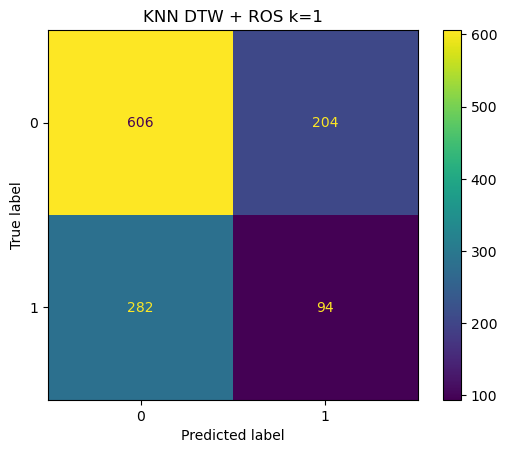

Fitting KNN DTW + oversampling with k=3

KNN DTW + ROS k=3
              precision    recall  f1-score   support

           0       0.69      0.68      0.68       810
           1       0.33      0.34      0.34       376

    accuracy                           0.57      1186
   macro avg       0.51      0.51      0.51      1186
weighted avg       0.58      0.57      0.57      1186



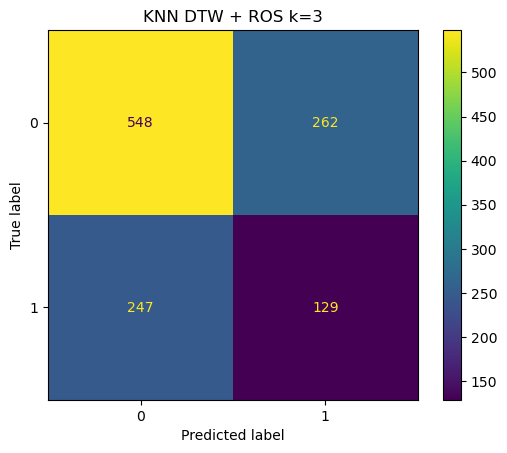

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,n_neighbors,distance,imbalance_strategy
1,KNN DTW + ROS k=3,0.570826,0.509814,0.509616,0.509814,0.509621,0.575372,0.570826,0.573017,3,dtw,random_oversampling
0,KNN DTW + ROS k=1,0.590219,0.499074,0.498934,0.499074,0.496356,0.566083,0.590219,0.575920,1,dtw,random_oversampling


In [26]:
# KNN DTW with random oversampling

from tslearn.neighbors import KNeighborsTimeSeriesClassifier

knn_dtw_os_results = []

for n_neighbors in [1, 3]:
    print(f"Fitting KNN DTW + oversampling with k={n_neighbors}")

    model = KNeighborsTimeSeriesClassifier(
        n_neighbors=n_neighbors,
        metric="dtw",
        weights="distance",
        n_jobs=-1
    )

    model.fit(X_train_ts_os, y_train_os)
    y_pred = model.predict(X_test_ts)

    result = evaluate_classifier(
        model_name=f"KNN DTW + ROS k={n_neighbors}",
        y_true=y_test,
        y_pred=y_pred
    )

    result["n_neighbors"] = n_neighbors
    result["distance"] = "dtw"
    result["imbalance_strategy"] = "random_oversampling"
    knn_dtw_os_results.append(result)

knn_dtw_os_results_df = pd.DataFrame(knn_dtw_os_results)

display(
    knn_dtw_os_results_df
    .sort_values("balanced_accuracy", ascending=False)
)